## 03 시본(Seaborn)

### 시각화를 위한 차트/그래프 유형
- 시각화 : 통계분석을 위한 시각화 / 비즈니스 분석을 위한 시각화
- 비즈니스를 위한 시각화 : 청중의 유형과 수준, 설득이 필요한 다양한 환경에 따라 적절하게 여러가지 차트 활용
- 통계 분석을 위한 시각화 : 데이터 자체가 가지는 특성에 좀 더 집중하는 경향
    ex) 특정 연속형 값이 정규분포 형태가 아닌 왜곡된 분포도, 칼럼들 간의 상관 관계, 이상치 값 도출 등

### 정보의 종류에 따른 시각화 유형
- 히스토그램 : 연속형 값에 대한 도수 분포를 나타냄. X축은 도수 분포 원하는 연속형 값의 구간, Y축은 해당 구간의 도수 분포(건수)를 나타냄.
- 바 플롯 : 특정 칼럼의 이산 값에 따른 다른 칼럼의 연속형 값(평균, 총합 등)을 막대 그래프 형태로 시각화함. (수직 막대 그래프 적용 시) X축은 특정 칼럼의 이산 값, Y축은 다른 칼럼의 연속형 값을 나타냄.
- 박스 플롯 : 연속형 값의 사분위(IQR)와 최대, 최소, 이상치 값을 시각화함. 보통 단일 칼럼의 연속형 값에 적용하지만, 이 연속형 값의 사분위를 다른 칼럼의 이산값별로 시각화할 때도 사용 가능함.
- 바이올린 플롯 : 히스토그램의 연속 확률 분포 곡선과 박스 플롯을 바이올린 형태로 함께 시각화함. 보통 단일 칼럼의 연속형 값에 적용하지만, 이 연속형 값의 분포를 다른 칼럼의 이산값별로 시각화할 때 유용함.
- 스캐터 플롯 : 산점도라고도 불리며, 2개의 연속형 값들을 X, Y 좌표상의 점으로 시각화해서 해당 값들이 어떻게 관계되어 있는지 나타냄.
- 상관 히트맵 : 다수의 연속형 칼럼들 간 상호 상관 관계를 시각화함.

### 히스토그램
- 시본, 맷플롯립, 판다스에서도 제공
- 연속형 값을 범위 또는 구간으로 그룹화해 개별 구간에 해당되는 데이터의 건수를 시각화
- hisplot() / displot() 함수 사용
- hisplot() : Axes 레벨 함수
- displot() : Figure 레벨 함수
  - height, aspect 인자로 크기 설정 / 가로 크기는 height*aspect





In [2]:
import pandas as pd

titanic_df =  pd.read_csv('titanic_train.csv')
titanic_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


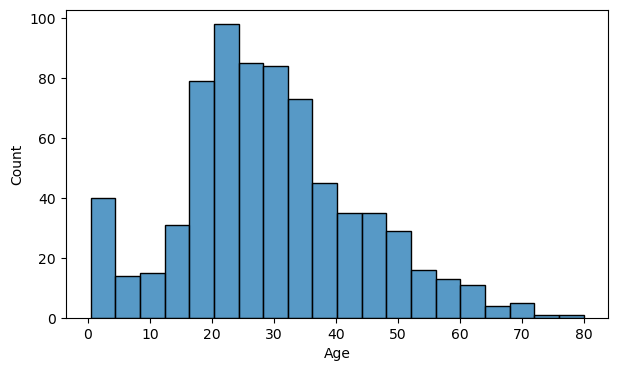

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시본에서도 plt.figure()의 figsize인자를 입력하여 전체 Figure의 크기 조절
plt.figure(figsize=(7, 4))

# Pandas DataFrame의 컬럼명을 자동으로 인식해서 xlabel값을 할당. ylabel 값은 histogram일때 Count 할당. 
sns.histplot(titanic_df['Age'], bins=20)
plt.show()

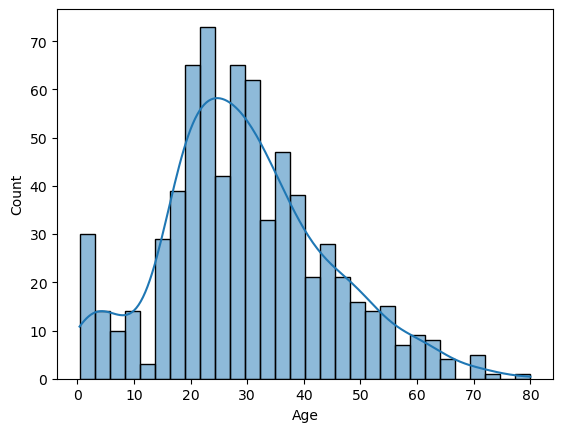

In [5]:
# 히스토그램의 연속 확률분포 곡선까지 시각화
sns.histplot(x='Age', data=titanic_df, bins=30, kde=True)
plt.show()

<Figure size 800x400 with 0 Axes>

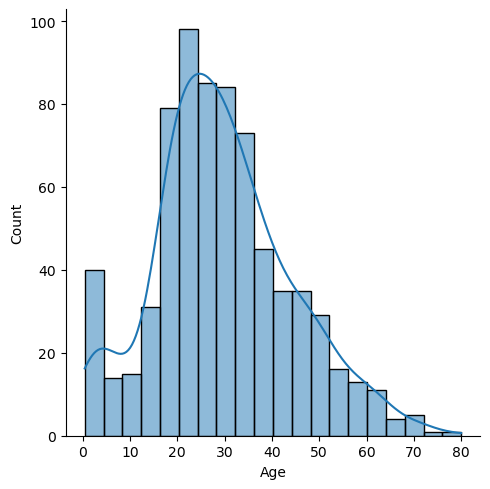

In [7]:
import seaborn as sns

# seaborn의 figure레벨 그래프는 plt.figure( )로 Figure 크기를 조절할 수 없습니다
plt.figure(figsize=(8, 4))

# Pandas DataFrame의 컬럼명을 자동으로 인식해서 xlabel값을 할당. ylabel 값은 histogram일때 Count 할당. 
sns.displot(x='Age', data=titanic_df, kde=True)
plt.show()

# 결과값은 설정한대로 (8,4)크기로 반환되지 않음

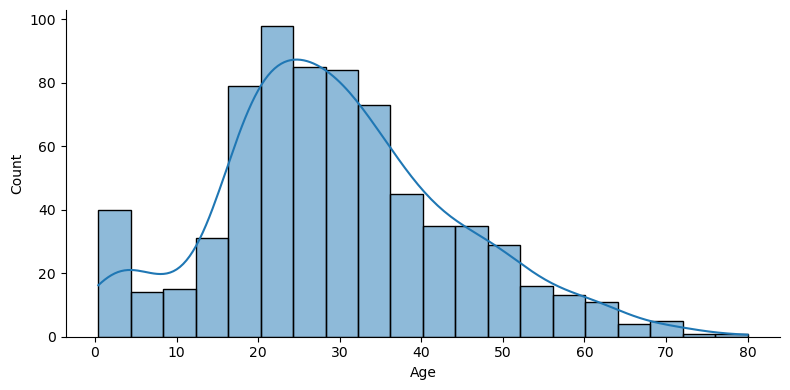

In [8]:
import seaborn as sns

sns.displot(titanic_df['Age'], kde=True, height=4, aspect=2)
plt.show()

### 카운트플롯
- 이산형 값의 건수를 막대 그래프 형태로 시각화 / 주로 카테고리성 칼럼 값별 건수를 시각화하는데 사용
- countplot()


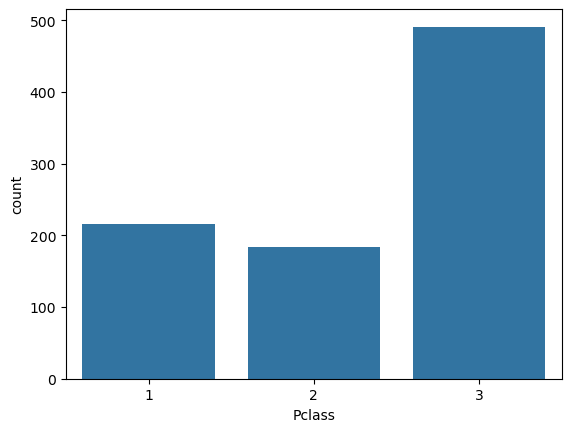

In [9]:
sns.countplot(x='Pclass', data=titanic_df)
plt.show()

### 바플롯
- 막대 그래프 형태의 플롯, 2차원 축 기반의 시각화에 활용
- X축 값이 이산형 값으로 값의 종류가 너무 많지 않을 때 유용하게 사용됨
- Y축 값은 Y축에 해당하는 칼럼값의 평균이나 총합으로 표현되는 연속형 값
- 수평 또는 수직 막대그래프 선택을 orient 인자로 설정 가능
    - orient v 일 경우 : 수직 막대그래프 / orient h 일 경우 : 수평 막대그래프
    - ex) Y축 값을 문자열, X축 값 숫자형으로 입력하면 자동 수평 막대그래프로 시각화



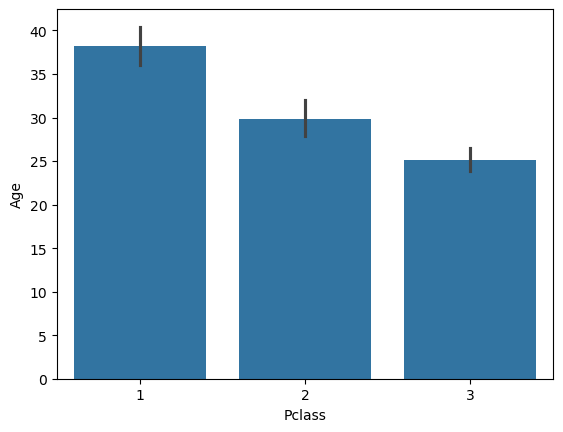

In [14]:
# 자동으로 xlabel, ylabel을 barplot( )의 x인자값인 Pclass, y인자값이 Age로 설정.
# 기본적으로  Y축 값의 평균 값을 나타냄
sns.barplot(x='Pclass', y='Age', data=titanic_df)
plt.show()

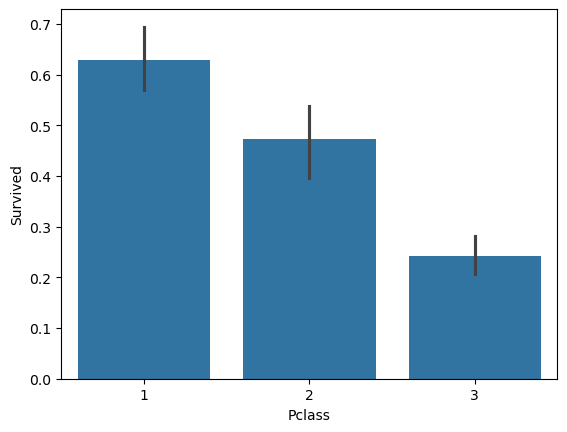

In [15]:
# survived 칼럼 값은 0과 1로 구성, Y값은 평균을 표현
sns.barplot(x='Pclass', y='Survived', data=titanic_df)
plt.show()

[]

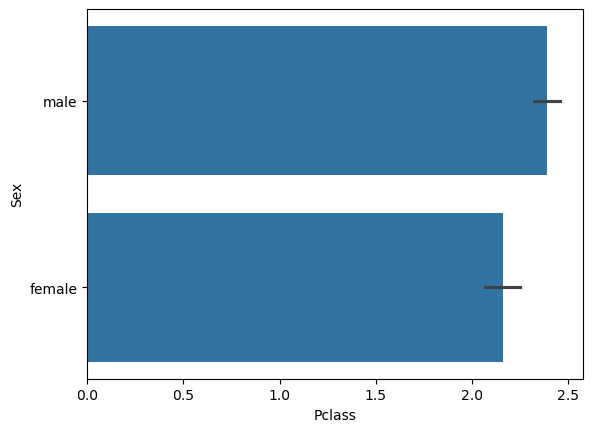

In [16]:
# y축을 문자값으로 설정하면 자동으로 수평 막대 그래프 변환
sns.barplot(x='Pclass', y='Sex', data=titanic_df)
plt.plot()

<Axes: xlabel='Name', ylabel='Sex'>

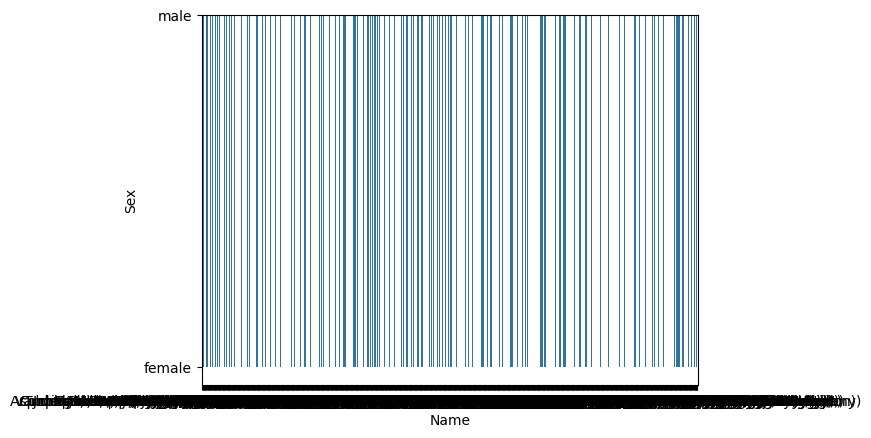

In [17]:
# x인자로 문자열인 Name을, y인자로 문자열인 Sex를 입력하므로 barplot은 오류를 발생. 
sns.barplot(x='Name', y='Sex', data=titanic_df)

/var/folders/w6/fhx2fj2d3t717fvxsdxb48180000gn/T/ipykernel_48019/2980788522.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=titanic_df, ci=None, estimator=sum)


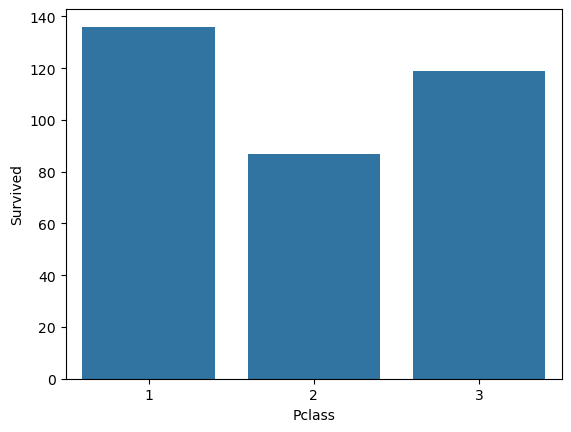

In [19]:
# estimator=sum을 적용하여 평균이 아니라 총합으로 표현
sns.barplot(x='Pclass', y='Survived', data=titanic_df, ci=None, estimator=sum)
plt.show()

### barplot() 함수의 hue 인자를 사용하여 시각화 정보를 추가적으로 세분화하기
- hue 인자를 통해 세부정보 추가적으로 전달


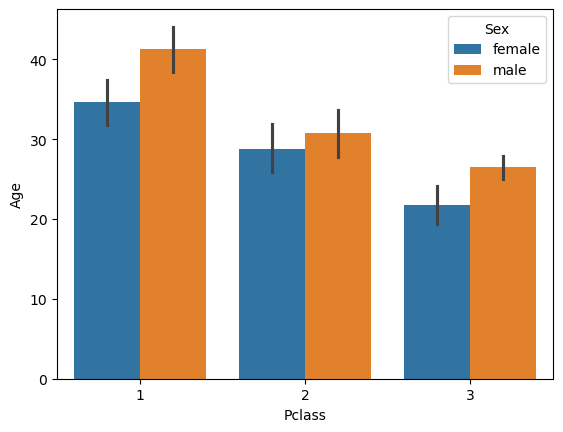

In [20]:
# 아래는 Pclass가 X축값이며 hue파라미터로 Sex를 설정
# 개별 Pclass 값 별로 Sex에 따른 Age 평균 값을 구함. 
sns.barplot(x='Pclass', y='Age', hue='Sex', data=titanic_df)
plt.show()

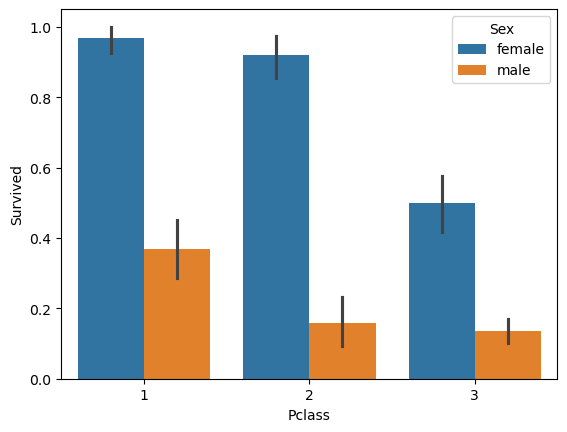

In [21]:
# 개별 Pclass 값 별로 Sex에 따른 Survived 평균 값을 구함.
# Pclass가 X축값이며 Survived가 Y축값. hue파라미터로 Sex를 설정 
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=titanic_df)
plt.show()

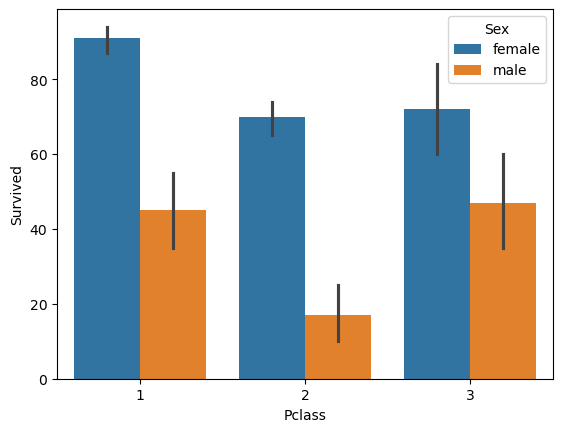

In [22]:
# 개별 Pclass 값 별로 Sex에 따른 Survived 평균 값을 구함.
# Pclass가 X축값이며 Survived가 Y축값. hue파라미터로 Sex를 설정 
sns.barplot(x='Pclass', y='Survived', hue='Sex', estimator=sum, data=titanic_df)
plt.show()

### 박스플롯
- 상자 수염 그래프 : 분위수를 기반, 분위수는 연속형 값에 적용해야 의미있는 정보, 연속형 값에 대한 IQR분위와 최소/최대 이상치 정보 시각화
- boxplot()
- 주요 인자 : x, y, data
- x에 입력시 수평 박스 플롯 / y에 입력시 수직 박스 플롯
- 단일 칼럼에 대한 분위수를 기반으로 하지만 추가적인 세분화 레벨에서도 적용 가능
    - 추가적인 세분화 레벨로 여러개의 수직 박스 플롯을 표현하고자 한다면 x인자는 반드시 이산형 값이 되어야함



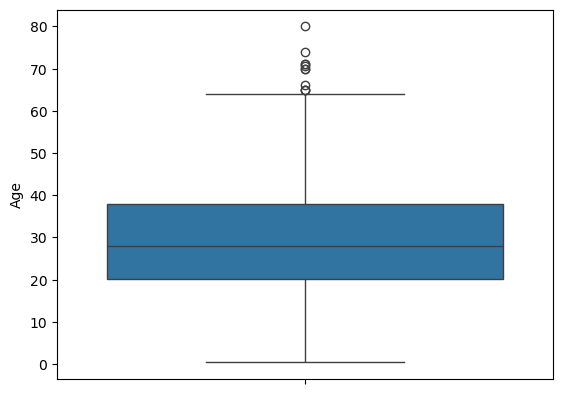

In [23]:
sns.boxplot(y='Age', data=titanic_df)
plt.show()

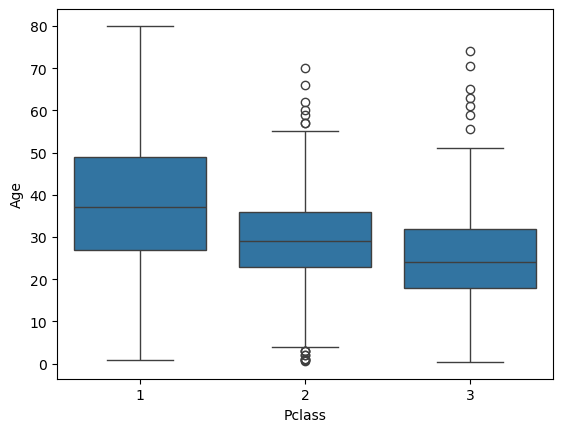

In [24]:
sns.boxplot(x='Pclass', y='Age', data=titanic_df)
plt.show()

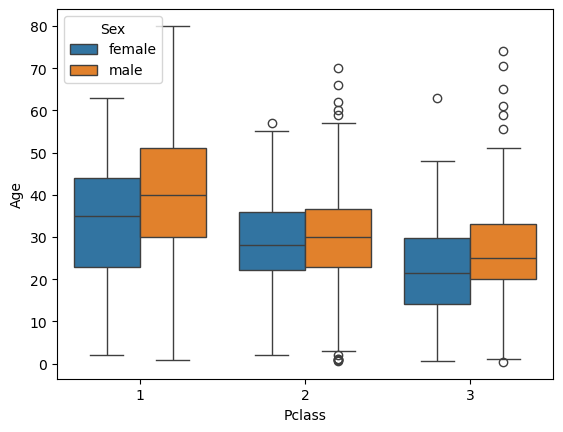

In [26]:
# hue로 추가적 정보 출력
sns.boxplot(x='Pclass', y='Age', hue='Sex', data=titanic_df)
plt.show()

### 바이올린 플롯
- 히스토그램의 연속 확률 분포 곡선과 박스 플롯을 함께 시각화
- 연속형 값에 적용해야 의미 있는 정보로 시각화
- violinplot()
- x, y인자로 연속형 값 입력, y에 입력 시 수직 바이올린 플롯, x에 입력 시 수평 바이올린 플롯 나타냄
- 여러 이산값별로 여러 개의 히스토그램 연속 확률 분포 곡선들을 그려 줄 수 있는 장점


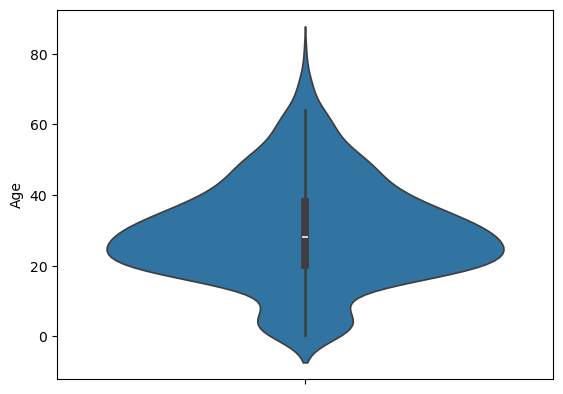

In [27]:
# Age 컬럼에 대한 수직 바이올린 플롯 시각화
sns.violinplot(y='Age', data=titanic_df)
plt.show()

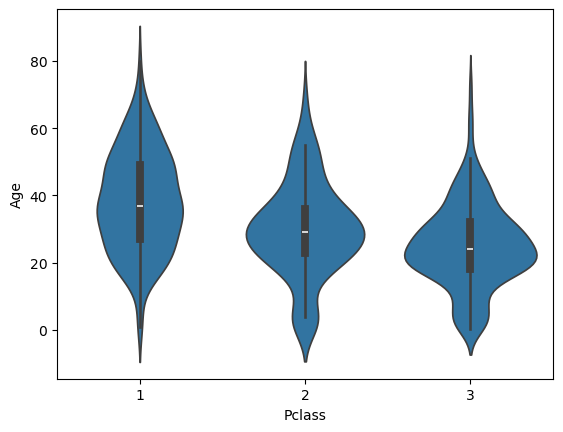

In [28]:
# x축값인 Pclass의 값별로 y축 값인 Age의 바이올린 플롯을 그림
# pClass값 별로 Age의 연속 확률분포 곡선과 박스플롯을 시각화하므로 pClass값별 Age 데이터 분포를 비교하여 볼수 있음.  
sns.violinplot(x='Pclass', y='Age', data=titanic_df)
plt.show()

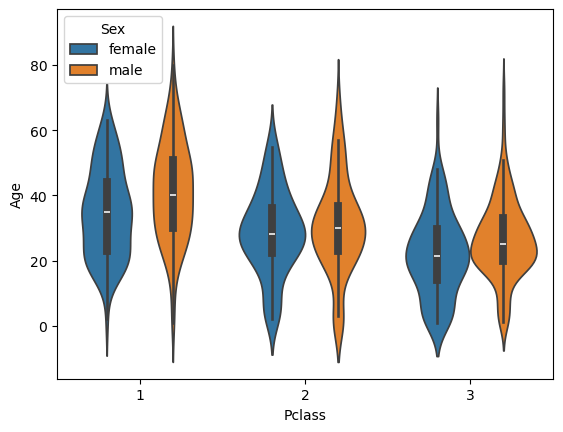

In [29]:
# x축값인 개별 Pclass내에서 Sex값 별로 y축 값인 Age의 바이올린 플롯을 그림 
sns.violinplot(x='Pclass', y='Age', hue='Sex', data=titanic_df)
plt.show()

### subplots를 이용하여 시본의 다양한 그래프를 시각화
- 시각화 함수 호출 시 이 ax인자에 개별 Axes 객체 할당


index: 0
index: 1
index: 2


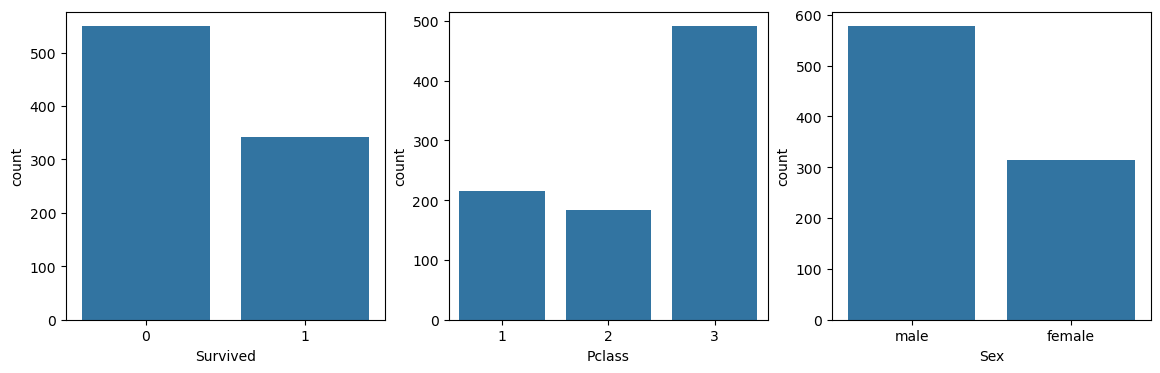

In [30]:
cat_columns = ['Survived', 'Pclass', 'Sex']

# nrows는 1이고 ncols는 컬럼의 갯수만큼인 subplots을 설정. 
fig, axs = plt.subplots(nrows=1, ncols=len(cat_columns), figsize=(14, 4))

# enumerate()는 리스트를 반복할 때 "몇 번째인지(index)"와 "그 값이 뭔지(column)"를 동시에 꺼내주는 함수
# 그냥 for column in cat_columns:라고만 하면 값만 나오고 "지금 몇 번째 반복인지"는 알 수 없는데, enumerate()를 씌우면 그 번호까지 같이 나와요.
for index, column in enumerate(cat_columns):
    print('index:', index)
    # seaborn의 Axes 레벨 function들은 ax인자로 subplots의 어느 Axes에 위치할지 설정. 
    sns.countplot(x=column, data=titanic_df, ax=axs[index])

<Axes: xlabel='Sex', ylabel='count'>

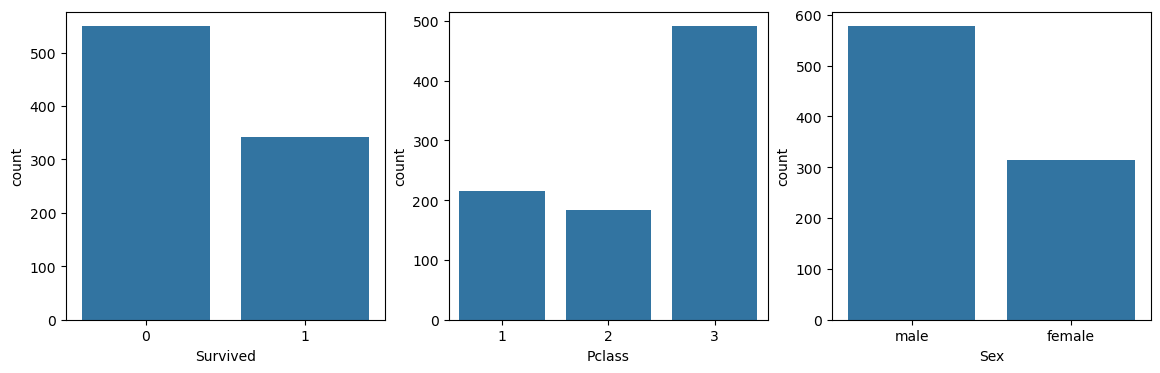

In [33]:
cat_columns = ['Survived', 'Pclass', 'Sex']

# nrows는 1이고 ncols는 컬럼의 갯수만큼인 subplots을 설정. 
fig, axs = plt.subplots(nrows=1, ncols=len(cat_columns), figsize=(14, 4))

# 같은결과
sns.countplot(x='Survived', data=titanic_df, ax=axs[0])
sns.countplot(x='Pclass',   data=titanic_df, ax=axs[1])
sns.countplot(x='Sex',      data=titanic_df, ax=axs[2])

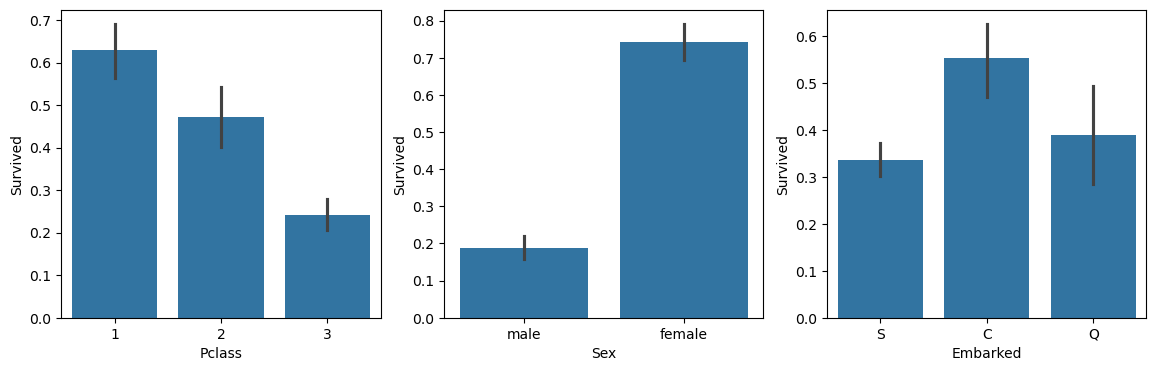

In [34]:
cat_columns = ['Pclass', 'Sex', 'Embarked']

# nrows는 1이고 ncols는 컬럼의 갯수만큼인 subplots을 설정. 
fig, axs = plt.subplots(nrows=1, ncols=len(cat_columns), figsize=(14, 4))

for index, column in enumerate(cat_columns):
    # seaborn의 Axes 레벨 function들은 ax인자로 subplots의 어느 Axes에 위치할지 설정. 
    sns.barplot(x=column, y='Survived', data=titanic_df, ax=axs[index])

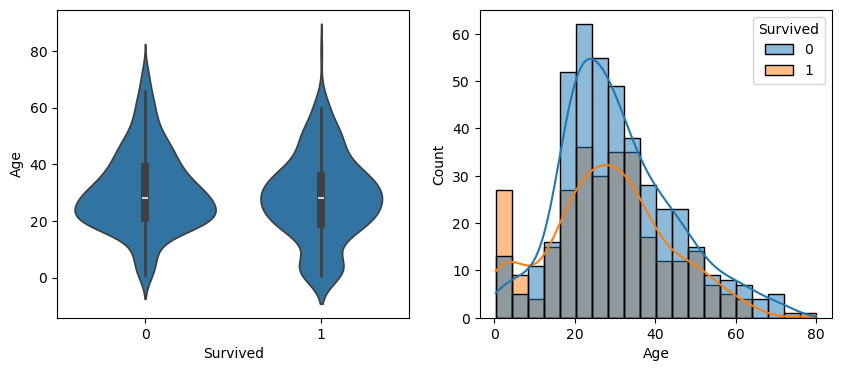

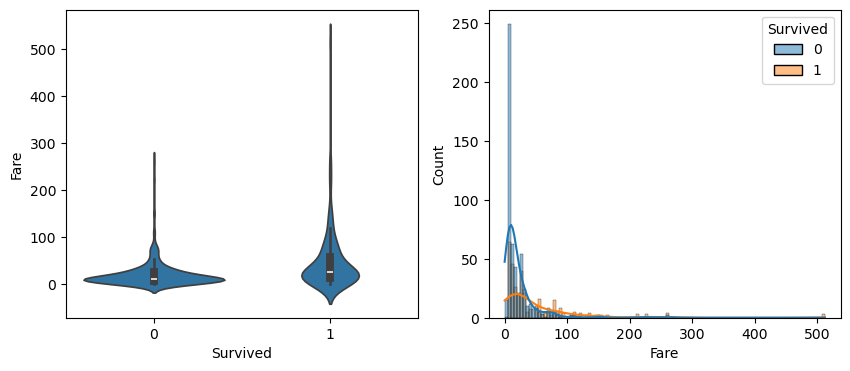

In [35]:
cont_columns = ['Age', 'Fare']

# 리스트로 할당된 컬럼들의 개수만큼 루프 수행.
for column in cont_columns:
    # 왼쪽에는 바이올린 플롯, 오른쪽에는 히스토그램을 시각화 하기 위해 nrows는 1, ncols=2인 서브플롯 생성. 
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
    # 왼쪽 Axes객체에는 Survived값 0, 1별 개별 컬럼의 바이올린 플롯 시각화.
    sns.violinplot(x='Survived', y=column, data=titanic_df, ax=axs[0])
    # 오른쪽 Axes객체에는 Survived 값에 따른 개별 컬럼의 히스토그램 시각화 
    sns.histplot(x=column, data=titanic_df, kde=True, hue='Survived', ax=axs[1])

### 산점도, 스캐터 플롯
- 좌표상에 점을 표시하여 변수 간의 관계를 나타냄
- 변수 간의 관계 시각화
- 일반적으로 산점도에 사용되는 X축 값, Y축 값 모두 연속형 숫자값을 적용해야 의미 있는 시각화 정보 얻음
- scatterplot()
- hue, style : 세분화된 추가정보 제공해주는 인자

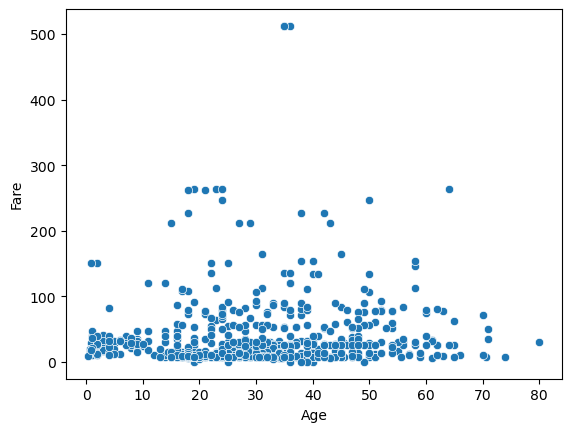

In [36]:
# X축값으로 Age를, Y축값으로 Fare를 설정
sns.scatterplot(x='Age', y='Fare', data=titanic_df)
plt.show()

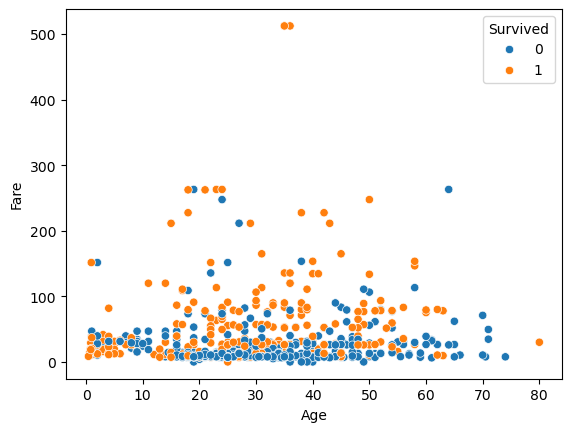

In [38]:
sns.scatterplot(x='Age', y='Fare',hue='Survived', data=titanic_df)
plt.show()

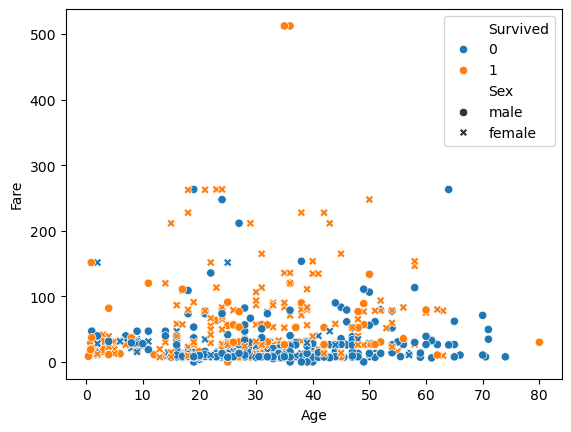

In [39]:
sns.scatterplot(x='Age', y='Fare',hue='Survived', style='Sex', data=titanic_df)
plt.show()

### 상관 히트맵
- 히트맵 : 열 + 지도
- 수치값을 온도를 연상시키는 다양한 색상으로 표현하는 것을 특징으로 함
- 상관계수 : 두 속성(변수/칼럼/피처)들 간의 선형적인 연관 관계를 수치화한 값
    - 서로 상관이 없으면 0 / 같은 방향으로 완전히 동일하면 1 / 반대 방향으로 완전히 동일하면 -1
- heatmap()
- corr() 메서드를 호출하여 상관계수를 가지는 DataFrame 생성
- cmap 인자 : 설정하지 않으면 기본으로 'rocket'설정(색깔)
- annot 인자 : True - 상관계수값 표시 /False - 상관계수값 표시 안함
- fmt 인자 : 숫자값 포맷 변환
    - ex) fmt='.1f'로 설정하면 소수점 한자리까지만 상관계수값 표시
- cbar 인자 : True - 숫자값에 따른 색깔 기준 막대로 표시 / False - 색깔 기준 막대 표시하지 않음 (생략할 경우 True)






In [44]:
corr_df = titanic_df.corr(numeric_only=True)
corr_df

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


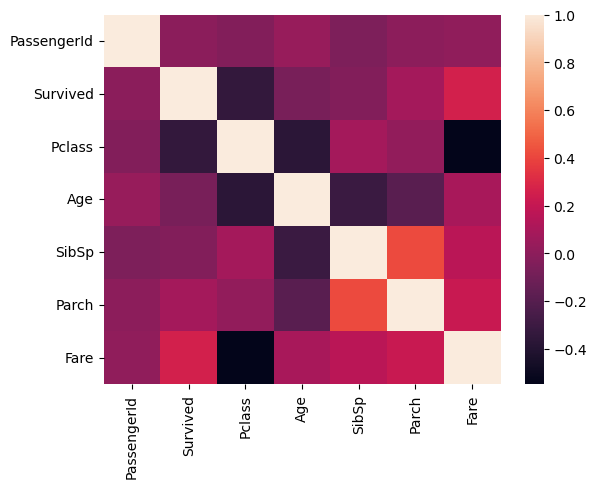

In [46]:
# 상관계수를 DataFrame으로 구하고 이를 heatmap()의 인자로 입력  
corr = titanic_df.corr(numeric_only=True)
sns.heatmap(corr)
plt.show()

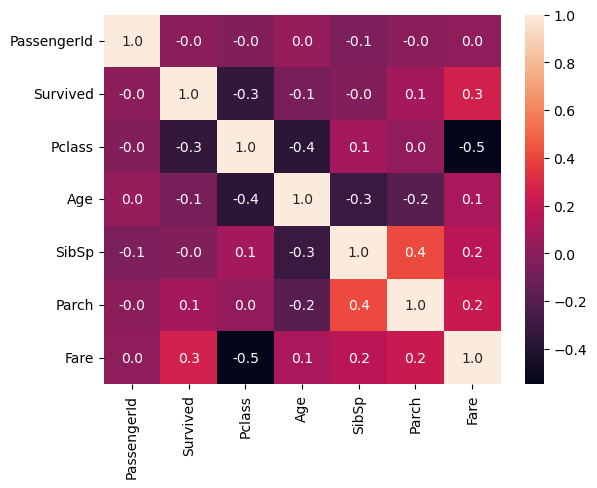

In [49]:
sns.heatmap(corr, annot=True, fmt='.1f', cbar=True)
plt.show()